   TASK 2: STOCK PRICE PREDICTION

📡 Downloading AAPL data (2y) from Yahoo Finance ...
   ✅ Loaded 502 trading days  |  2024-02-28 → 2026-02-27

🔧 Engineering features ...
   Train samples: 385 | Test samples: 97

🤖 Training models ...

📊 Model Evaluation on Test Set:

   📌 Linear Regression
      MAE  : $2.644
      RMSE : $3.806
      MAPE : 1.00%
      R²   : 0.8414

   📌 Random Forest
      MAE  : $13.268
      RMSE : $15.321
      MAPE : 4.88%
      R²   : -1.5703

📊 Plotting predictions ...


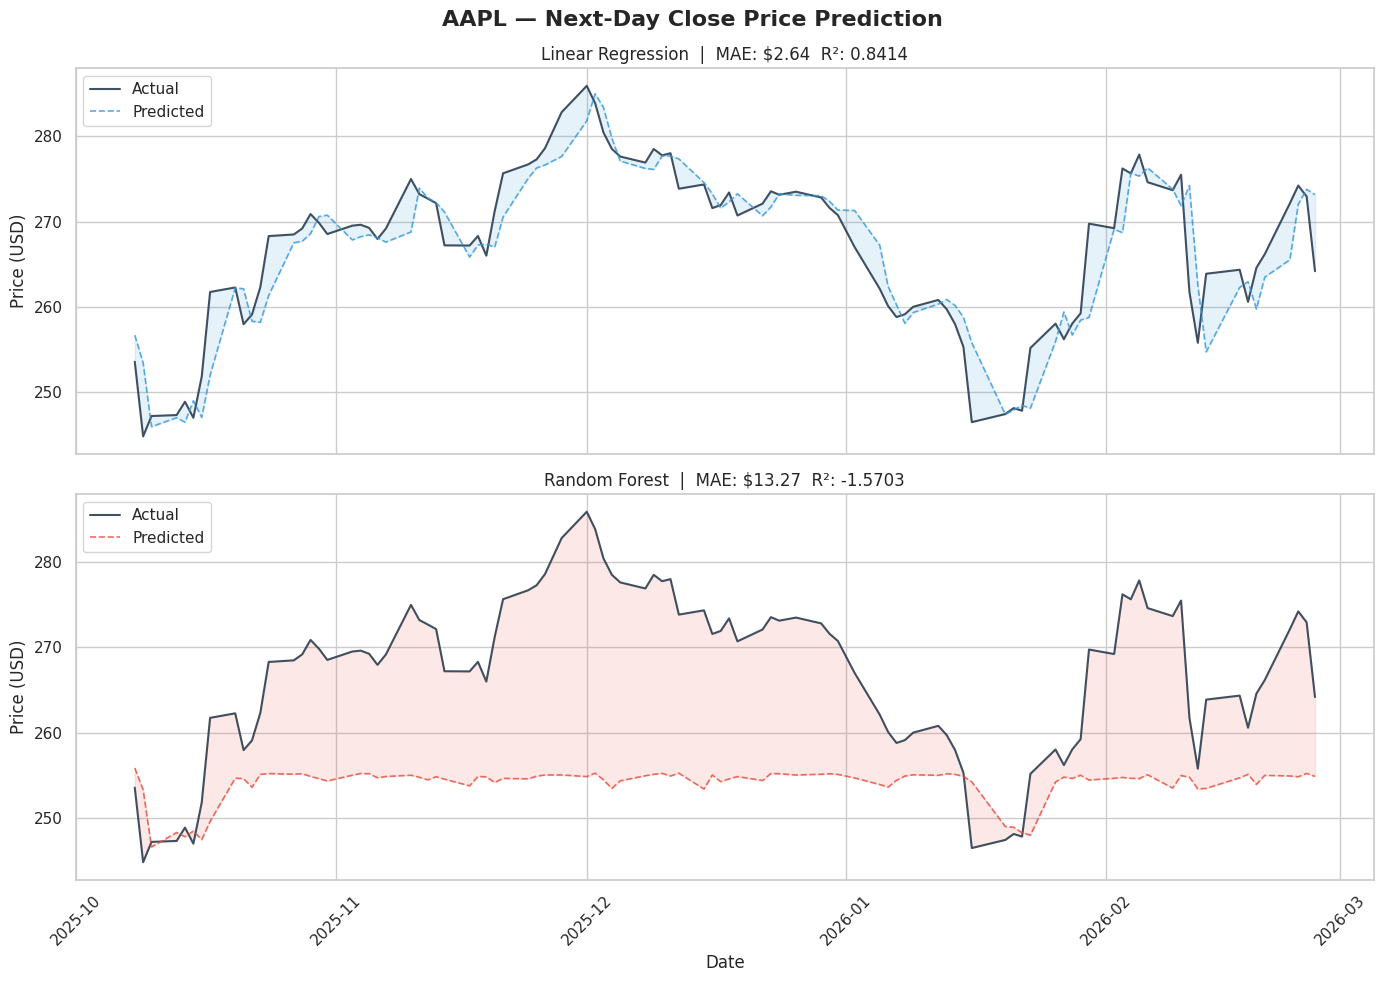

   ✅ Saved → task2_predictions.png


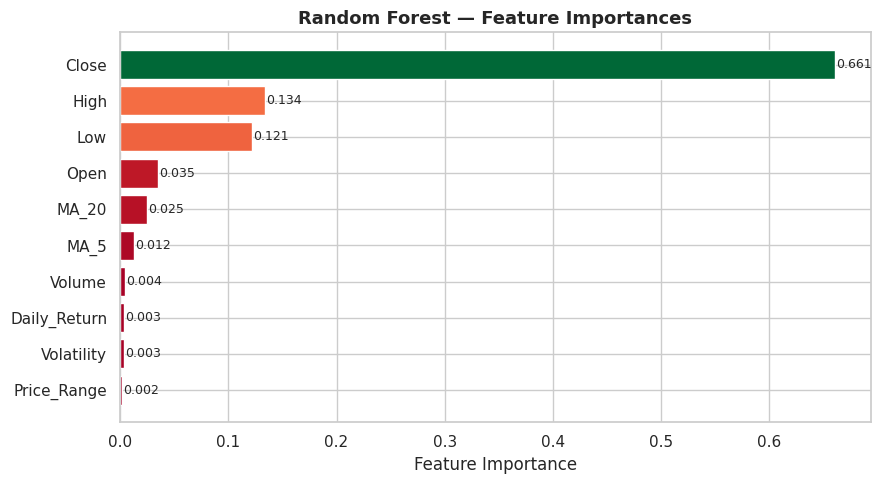

   ✅ Saved → task2_feature_importance.png


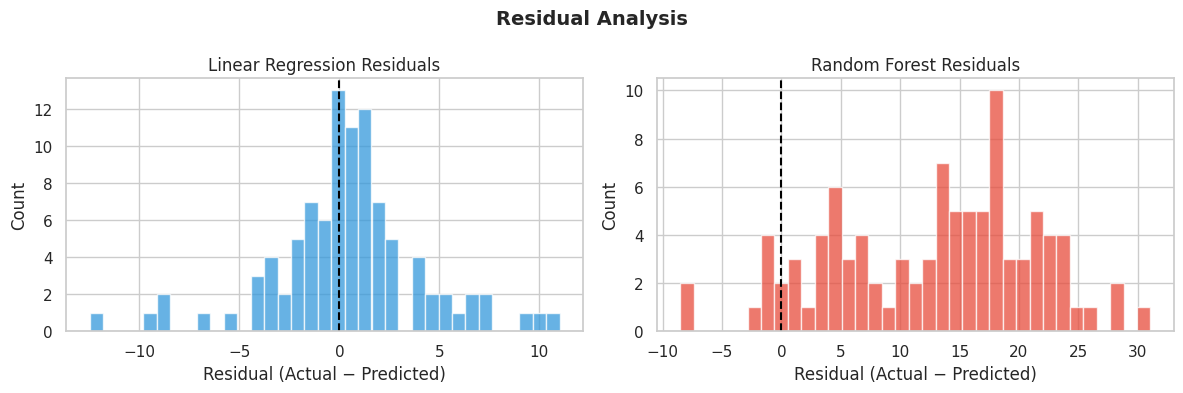

   ✅ Saved → task2_residuals.png


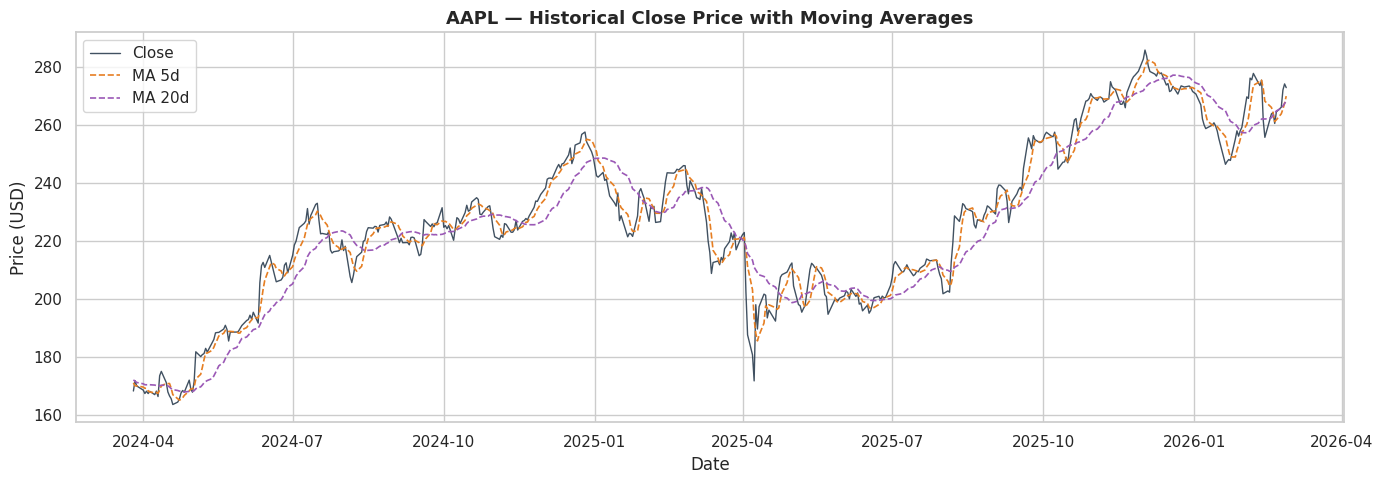

   ✅ Saved → task2_historical.png

✅ TASK 2 COMPLETE — All visualizations saved.



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing   import StandardScaler

sns.set_theme(style="whitegrid")

print("=" * 55)
print("   TASK 2: STOCK PRICE PREDICTION")
print("=" * 55)

# ─────────────────────────────────────────────
# 1. FETCH HISTORICAL DATA
# ─────────────────────────────────────────────
TICKER = "AAPL"          # Change to any valid ticker, e.g. "TSLA", "MSFT"
PERIOD = "2y"            # 2 years of history

print(f"\n📡 Downloading {TICKER} data ({PERIOD}) from Yahoo Finance ...")
raw = yf.download(TICKER, period=PERIOD, progress=False)

if raw.empty:
    raise ValueError(f"No data returned for {TICKER}. Check ticker or internet connection.")

# Flatten MultiIndex columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
df.dropna(inplace=True)
print(f"   ✅ Loaded {len(df)} trading days  |  {df.index[0].date()} → {df.index[-1].date()}")

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────
print("\n🔧 Engineering features ...")

df["MA_5"]          = df["Close"].rolling(5).mean()   # 5-day moving average
df["MA_20"]         = df["Close"].rolling(20).mean()  # 20-day moving average
df["Daily_Return"]  = df["Close"].pct_change()        # daily % return
df["Volatility"]    = df["Daily_Return"].rolling(5).std()
df["Price_Range"]   = df["High"] - df["Low"]          # intraday range
df["Target"]        = df["Close"].shift(-1)           # NEXT day's close (what we predict)

df.dropna(inplace=True)

FEATURES = ["Open", "High", "Low", "Close", "Volume",
            "MA_5", "MA_20", "Daily_Return", "Volatility", "Price_Range"]
TARGET   = "Target"

X = df[FEATURES].values
y = df[TARGET].values
dates = df.index

# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT  (chronological — no shuffle)
# ─────────────────────────────────────────────
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test       = dates[split:]

scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"   Train samples: {len(X_train)} | Test samples: {len(X_test)}")

# ─────────────────────────────────────────────
# 4. TRAIN MODELS
# ─────────────────────────────────────────────
print("\n🤖 Training models ...")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_preds = lr.predict(X_test_s)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# ─────────────────────────────────────────────
# 5. EVALUATE
# ─────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n   📌 {name}")
    print(f"      MAE  : ${mae:.3f}")
    print(f"      RMSE : ${rmse:.3f}")
    print(f"      MAPE : {mape:.2f}%")
    print(f"      R²   : {r2:.4f}")
    return mae, rmse, r2, mape

print("\n📊 Model Evaluation on Test Set:")
lr_metrics = evaluate("Linear Regression", y_test, lr_preds)
rf_metrics = evaluate("Random Forest",     y_test, rf_preds)

# ─────────────────────────────────────────────
# 6. PLOTS
# ─────────────────────────────────────────────

# ── Figure 1: Actual vs Predicted ──────────────────────────
print("\n📊 Plotting predictions ...")
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"{TICKER} — Next-Day Close Price Prediction", fontsize=16, fontweight="bold")

for ax, name, preds, color in [
    (axes[0], "Linear Regression", lr_preds, "#3498db"),
    (axes[1], "Random Forest",     rf_preds, "#e74c3c"),
]:
    ax.plot(dates_test, y_test,   color="#2c3e50", linewidth=1.5, label="Actual",    alpha=0.9)
    ax.plot(dates_test, preds,    color=color,     linewidth=1.2, label="Predicted", alpha=0.8, linestyle="--")
    ax.fill_between(dates_test,
                    y_test, preds,
                    alpha=0.12, color=color)
    ax.set_title(f"{name}  |  MAE: ${mean_absolute_error(y_test, preds):.2f}  "
                 f"R²: {r2_score(y_test, preds):.4f}", fontsize=12)
    ax.set_ylabel("Price (USD)")
    ax.legend(loc="upper left")
    ax.tick_params(axis="x", rotation=45)

axes[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("task2_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Saved → task2_predictions.png")

# ── Figure 2: Random Forest Feature Importance ─────────────
fig, ax = plt.subplots(figsize=(9, 5))
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
bars = ax.barh(importances.index, importances.values,
               color=plt.cm.RdYlGn(importances.values / importances.values.max()))
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest — Feature Importances", fontsize=13, fontweight="bold")
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("task2_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Saved → task2_feature_importance.png")

# ── Figure 3: Residual Distribution ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Residual Analysis", fontsize=14, fontweight="bold")

for ax, name, resid, color in [
    (axes[0], "Linear Regression", y_test - lr_preds, "#3498db"),
    (axes[1], "Random Forest",     y_test - rf_preds, "#e74c3c"),
]:
    ax.hist(resid, bins=35, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
    ax.set_title(f"{name} Residuals")
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("task2_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Saved → task2_residuals.png")

# ── Figure 4: Historical Close + Moving Averages ───────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Close"],  color="#2c3e50", linewidth=1,   label="Close",  alpha=0.9)
ax.plot(df.index, df["MA_5"],   color="#e67e22", linewidth=1.2, label="MA 5d",  linestyle="--")
ax.plot(df.index, df["MA_20"],  color="#9b59b6", linewidth=1.2, label="MA 20d", linestyle="--")
ax.set_title(f"{TICKER} — Historical Close Price with Moving Averages", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.savefig("task2_historical.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Saved → task2_historical.png")

print("\n✅ TASK 2 COMPLETE — All visualizations saved.\n")